In [19]:
%matplotlib notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk
import mglearn
import warnings
warnings.simplefilter('ignore')

<IPython.core.display.Javascript object>


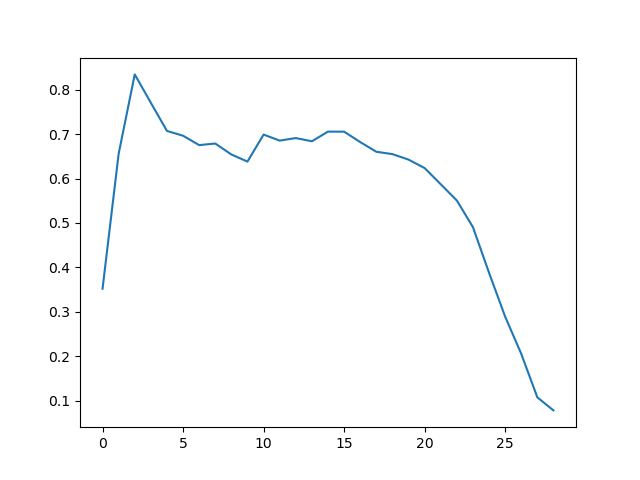

[0.3519867415115093, 0.6557491875542131, 0.8344172446249604, 0.7704189018456431, 0.7071381144011731, 0.6963552119009186, 0.6752134587675717, 0.6788241385739405, 0.6541236379533191, 0.6381920637966467, 0.6989374099426371, 0.6853827358907443, 0.6911059364120702, 0.6838927115096367, 0.7056253886346188, 0.7055036077606035, 0.6820756456432953, 0.6602566052151161, 0.6549724049644474, 0.6426278791053572, 0.6235907059927865, 0.5871702612817051, 0.5505619887906388, 0.49066448924264683, 0.38781499198920333, 0.28919932731909004, 0.20537088255887329, 0.10742542546232337, 0.07808201754010857]


In [53]:
from sklearn.model_selection import train_test_split as tts
from sklearn.neighbors import KNeighborsRegressor as knr

X, y = mglearn.datasets.make_wave(n_samples=40)
X_train, X_test, y_train, y_test = tts(X, y, random_state=0)
# print(X.shape, y.shape)

# Variable n's
tests = []

for i in range(1, 30):
    reg = knr(n_neighbors=i)
    reg.fit(X_train, y_train)
    tests.append(reg.score(X_test, y_test))
plt.plot(tests)
print(tests)

In [54]:
# Hence Max Value occurs for 3:
reg = knr(n_neighbors=3)
reg.fit(X_train, y_train)
print("Predictions: ", reg.predict(X_test))
print("Actual: ", y_test)

Predictions:  [-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]
Actual:  [ 0.37299129  0.21778193  0.96695428 -1.38773632 -1.05979555 -0.90496988
  0.43655826  0.7789638  -0.54114599 -0.95652133]


In [55]:
# As,this is a regression problem, we use r-squared score.
print(reg.score(X_test, y_test))

0.8344172446249604


<IPython.core.display.Javascript object>


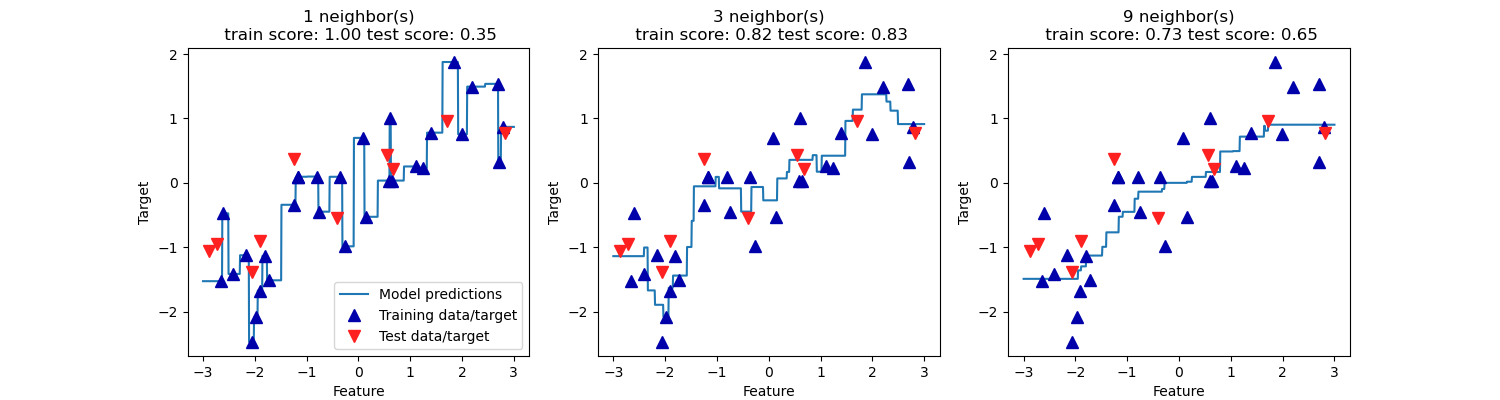

In [63]:
# Plotting the Regressions Created for different values of n:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Creating 1000 datapoints evenly spaced between -3 and +3:
# Performed using np.linspace
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

for i, ax in zip([1, 3, 9], axes):
    reg = knr(n_neighbors=i)
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)
    ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
             i, reg.score(X_train, y_train),
                 reg.score(X_test, y_test)))
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target","Test data/target"], loc="best")


In [ ]:
"""
Basically 2 Important properties determine the k-NN Classifier's Accuracy and Predictions:
These are:
1. Number of neighbours: 
Lesser number of neighbours tend to overfit the data while
Higher number of neighbours tend to underfit the data.
Thus, it is necessary to find the sweet spot bettween these 2 to have an accurate result.
2. Distance from every sample point:
The distance that is chosen by default is the Eulerian Distance.
How ever there exists a distance argument within the KNR() to improve the model.
However Eulerian Distance is often good enough.
"""

In [ ]:
"""
Drawbacks of k-NN:
The drawback of KNN Model is finding the sweet spot, which inturn makes the algorithm quiet slow.
The speed of knn is slow and thus other models are used over it.
"""